# 02. Data Cleaning

Notebook 01 left me with a list of cleaning decisions to make. I want to land on a single processed parquet for train and another for test, with sensible dtypes, the missing-value strategy already applied, and `price_usd` in a form that does not blow up tree splits.

I am keeping the cleaning conservative on purpose. LightGBM tolerates NaN natively, so I will only impute or transform when there is a clear reason to.

In [1]:
import gc
import os
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import seaborn as sns

warnings.filterwarnings("ignore", category=RuntimeWarning, message="Mean of empty slice")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROC_DIR = PROJECT_ROOT / "data" / "processed"
PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = PROJECT_ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

TRAIN_RAW = RAW_DIR / "training_set_VU_DM.csv"
TEST_RAW = RAW_DIR / "test_set_VU_DM.csv"
TRAIN_OUT = PROC_DIR / "train_clean.parquet"
TEST_OUT = PROC_DIR / "test_clean.parquet"


def rss_gb():
    return psutil.Process(os.getpid()).memory_info().rss / 1e9


print(f"baseline RSS: {rss_gb():.2f} GB")

baseline RSS: 0.22 GB


## Load

Same setup as notebook 01. I read the raw CSVs without specifying dtypes, then I will downcast at the end.

In [2]:
t0 = time.time()
train = pd.read_csv(TRAIN_RAW)
test = pd.read_csv(TEST_RAW)
print(f"loaded both files in {time.time() - t0:.1f}s, RSS {rss_gb():.2f} GB")
print(f"train: {train.shape}, test: {test.shape}")

loaded both files in 26.1s, RSS 4.42 GB
train: (4958347, 54), test: (4959183, 50)


## Date-time parsing

The `date_time` column is a string. I want it as a real timestamp so I can derive features later (month, weekday, hour) without re-parsing.

In [3]:
for df in (train, test):
    df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")

print("train date range:", train["date_time"].min(), "->", train["date_time"].max())
print("test  date range:", test["date_time"].min(), "->", test["date_time"].max())

train date range: 2012-11-01 00:08:29 -> 2013-06-30 23:58:24
test  date range: 2012-11-01 00:01:37 -> 2013-06-30 23:55:44


Train and test both span 2012-11-01 to 2013-06-30. So the split is not a clean before/after; test searches are interleaved with train searches in time. This actually simplifies historical priors: I can aggregate over all train data without worrying about temporal leakage into test, because the relevant labels (`click_bool`, `booking_bool`) only exist for train rows anyway. The risk is only intra-train leakage when computing priors for training rows, which I will handle with a K-fold scheme in notebook 03.

## Visitor-history flag

In notebook 01 I noticed that the two `visitor_hist_*` columns are 95% empty and that rows with history book at a measurably higher rate. I want a single boolean indicator alongside the original numerics, so a tree can split on "has history yes/no" without having to learn "is NaN" twice.

In [4]:
for df in (train, test):
    df["has_visitor_history"] = df["visitor_hist_adr_usd"].notna().astype("int8")

print("has_visitor_history rate, train:", train["has_visitor_history"].mean())
print("has_visitor_history rate, test :", test["has_visitor_history"].mean())

has_visitor_history rate, train: 0.05102264928210954
has_visitor_history rate, test : 0.05134394112901258


Roughly the same 5% rate in both files, so the flag is consistent.

## Price transformation

Looking at all 4.96M rows now, the maximum `price_usd` is $19.7M (the 500k-row sample in EDA only saw $4.3M). log1p compresses that monster to about 16.8, easily inside a model-friendly range. I will keep the raw `price_usd` because it can still be useful for ratio-style features later, and add a log column alongside it.

In [5]:
for df in (train, test):
    df["price_usd"] = df["price_usd"].astype("float32")
    df["log1p_price"] = np.log1p(df["price_usd"]).astype("float32")

print(train[["price_usd", "log1p_price"]].describe(percentiles=[0.5, 0.9, 0.99]))

          price_usd   log1p_price
count  4.958347e+06  4.958347e+06
mean   2.542097e+02  4.855749e+00
std    1.600124e+04  6.153603e-01
min    0.000000e+00  0.000000e+00
50%    1.220000e+02  4.812184e+00
90%    2.770000e+02  5.627621e+00
99%    5.990000e+02  6.396930e+00
max    1.972633e+07  1.679746e+01


log1p price now sits between 0 and around 16, which is a much friendlier range for any follow-up arithmetic (within-search z-scores, differences against `prop_log_historical_price`, and so on). The pair of histograms below shows the before-and-after on a 1M-row sample.

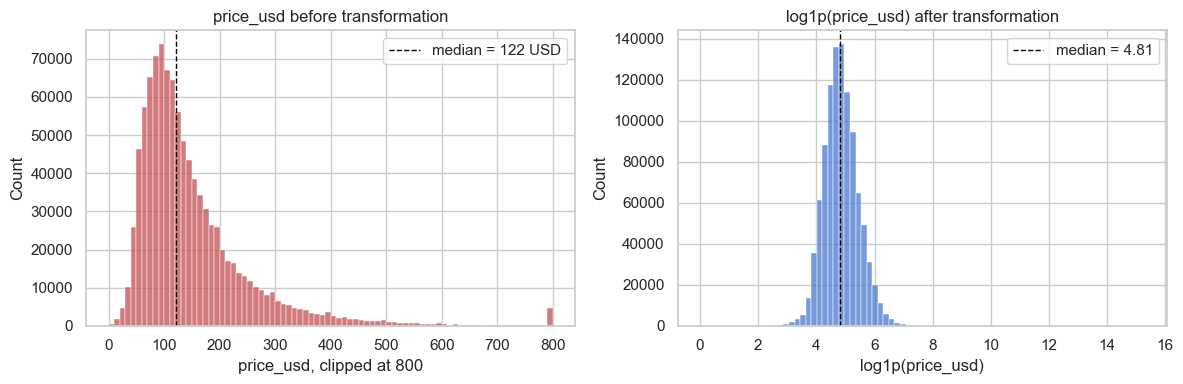

170

In [6]:
sample = train["price_usd"].sample(1_000_000, random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
sns.histplot(sample.clip(upper=800), bins=80, ax=ax, color="#c44e52", edgecolor="white")
ax.axvline(sample.median(), color="black", linestyle="--", linewidth=1, label=f"median = {sample.median():.0f} USD")
ax.set_xlabel("price_usd, clipped at 800")
ax.set_title("price_usd before transformation")
ax.legend(loc="upper right")
ax = axes[1]
log_sample = np.log1p(sample)
sns.histplot(log_sample, bins=80, ax=ax, color="#4878d0", edgecolor="white")
ax.axvline(log_sample.median(), color="black", linestyle="--", linewidth=1, label=f"median = {log_sample.median():.2f}")
ax.set_xlabel("log1p(price_usd)")
ax.set_title("log1p(price_usd) after transformation")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIG_DIR / "cleaning_price_log_transform.png", dpi=150)
plt.show()
del sample, log_sample
gc.collect()

I am NOT clipping or winsorising `price_usd` here. The plan from notebook 01 was to test winsorise vs log vs raw on a small sanity ranker; I will run that comparison in notebook 03 once the feature set is in place, because the choice depends on what other features are around. For now both columns survive into the parquet.

## Competitor block

24 columns named `compN_rate`, `compN_inv`, `compN_rate_percent_diff`. They are mostly NaN. Two things I want to do:

1. Coerce them to a small float dtype so they cost less.
2. Optionally synthesise a couple of cheap aggregate features: how many competitors had a quote at all, and the average percent-diff when they did. Both are leakage-free because they only use the row's own competitor block.

In [7]:
comp_rate_cols = [c for c in train.columns if c.startswith("comp") and c.endswith("_rate")]
comp_inv_cols = [c for c in train.columns if c.startswith("comp") and c.endswith("_inv")]
comp_pdiff_cols = [c for c in train.columns if c.startswith("comp") and c.endswith("_rate_percent_diff")]

print(f"rate cols: {len(comp_rate_cols)}, inv cols: {len(comp_inv_cols)}, pdiff cols: {len(comp_pdiff_cols)}")

for df in (train, test):
    rate_arr = df[comp_rate_cols].astype("float32").to_numpy()
    pdiff_arr = df[comp_pdiff_cols].astype("float32").to_numpy()
    df["comp_count_quoted"] = (~np.isnan(rate_arr)).sum(axis=1).astype("int8")
    df["comp_pdiff_mean"] = np.nanmean(pdiff_arr, axis=1).astype("float32")
    df["comp_rate_mean"] = np.nanmean(rate_arr, axis=1).astype("float32")
    for c in comp_rate_cols + comp_inv_cols:
        df[c] = df[c].astype("float32")
    for c in comp_pdiff_cols:
        df[c] = df[c].astype("float32")

print("train comp_count_quoted distribution:")
print(train["comp_count_quoted"].value_counts().sort_index())

rate cols: 8, inv cols: 8, pdiff cols: 8
train comp_count_quoted distribution:
comp_count_quoted
0    1716808
1     568001
2     798943
3    1052824
4     763172
5      47862
6      10716
7         21
Name: count, dtype: int64


1.72M rows have zero competitor quotes (35%); the remaining 65% have between one and seven, with a strong mode at three. I am keeping all 24 raw competitor columns plus the three aggregates (`comp_count_quoted`, `comp_pdiff_mean`, `comp_rate_mean`), on the assumption that a tree model can pick whichever is most useful and the storage cost is small.

## Type optimisation

Notebook 01 saw 2.2 GB train and 2.1 GB test in memory with default dtypes. The integer columns are mostly small (counts, IDs that fit in int32, booleans). Floats can usually go to float32 without measurable loss for tree splits. Let me downcast in one pass.

In [8]:
def downcast(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.select_dtypes(include=["int64"]).columns:
        col_max = df[col].max()
        col_min = df[col].min()
        if col_max <= np.iinfo("int32").max and col_min >= np.iinfo("int32").min:
            df[col] = df[col].astype("int32")
    for col in df.select_dtypes(include=["float64"]).columns:
        df[col] = df[col].astype("float32")
    return df


before_train = train.memory_usage(deep=True).sum() / 1e9
before_test = test.memory_usage(deep=True).sum() / 1e9
train = downcast(train)
test = downcast(test)
after_train = train.memory_usage(deep=True).sum() / 1e9
after_test = test.memory_usage(deep=True).sum() / 1e9
print(f"train memory: {before_train:.2f} GB -> {after_train:.2f} GB")
print(f"test  memory: {before_test:.2f} GB -> {after_test:.2f} GB")
print(f"current RSS : {rss_gb():.2f} GB")

train memory: 1.72 GB -> 1.16 GB
test  memory: 1.56 GB -> 1.08 GB
current RSS : 5.69 GB


About a third of the memory gone (1.72 GB to 1.16 GB on train, 1.56 GB to 1.08 GB on test), with no precision loss that matters for trees. From here on I will keep dtypes stable.

## Group consistency sanity check

Cleaning should not drop rows or break the `srch_id` grouping. I want to confirm the train and test row counts and group counts are the same as I started with.

In [9]:
print(f"train rows: {len(train):,} (started at 4,958,347)")
print(f"test  rows: {len(test):,}  (started at 4,959,183)")
print(f"train srch_ids: {train['srch_id'].nunique():,} (started at 199,795)")
print(f"test  srch_ids: {test['srch_id'].nunique():,}")

assert len(train) == 4_958_347
assert len(test) == 4_959_183
assert train["srch_id"].nunique() == 199_795

train rows: 4,958,347 (started at 4,958,347)
test  rows: 4,959,183  (started at 4,959,183)
train srch_ids: 199,795 (started at 199,795)
test  srch_ids: 199,549


Asserts pass. Nothing was dropped.

## Final column inventory

Before saving I want to look at exactly what is going into the parquet, so future notebooks know what they will see.

In [10]:
print(f"train columns ({len(train.columns)}):")
for c in train.columns:
    print(f"  {c:32s}  {str(train[c].dtype):8s}  miss={train[c].isna().mean():.3f}")

train columns (59):
  srch_id                           int32     miss=0.000
  date_time                         datetime64[ns]  miss=0.000
  site_id                           int32     miss=0.000
  visitor_location_country_id       int32     miss=0.000
  visitor_hist_starrating           float32   miss=0.949
  visitor_hist_adr_usd              float32   miss=0.949
  prop_country_id                   int32     miss=0.000
  prop_id                           int32     miss=0.000
  prop_starrating                   int32     miss=0.000
  prop_review_score                 float32   miss=0.001
  prop_brand_bool                   int32     miss=0.000
  prop_location_score1              float32   miss=0.000
  prop_location_score2              float32   miss=0.220
  prop_log_historical_price         float32   miss=0.000
  position                          int32     miss=0.000
  price_usd                         float32   miss=0.000
  promotion_flag                    int32     miss=0.000
  src

Three new columns compared to raw: `has_visitor_history`, `log1p_price`, `comp_count_quoted`, `comp_pdiff_mean`, `comp_rate_mean` (so five new). Train still has `position`, `click_bool`, `booking_bool`, `gross_bookings_usd` for label-construction in notebook 03; test does not.

## Save

Parquet with snappy compression. PyArrow handles the typed columns and the timestamp without complaint.

In [11]:
t0 = time.time()
train.to_parquet(TRAIN_OUT, compression="snappy", index=False)
test.to_parquet(TEST_OUT, compression="snappy", index=False)
print(f"saved both parquets in {time.time() - t0:.1f}s")
print(f"train parquet: {TRAIN_OUT.stat().st_size / 1e6:.1f} MB")
print(f"test  parquet: {TEST_OUT.stat().st_size / 1e6:.1f} MB")

saved both parquets in 4.3s
train parquet: 106.4 MB
test  parquet: 101.1 MB


Round-trip verification: read each parquet back and confirm shape and dtypes.

In [12]:
roundtrip_train = pd.read_parquet(TRAIN_OUT)
roundtrip_test = pd.read_parquet(TEST_OUT)
assert roundtrip_train.shape == train.shape
assert roundtrip_test.shape == test.shape
assert (roundtrip_train.dtypes == train.dtypes).all()
print(f"round trip OK: train {roundtrip_train.shape}, test {roundtrip_test.shape}")
del roundtrip_train, roundtrip_test, train, test
gc.collect()
print(f"final RSS: {rss_gb():.2f} GB")

round trip OK: train (4958347, 59), test (4959183, 55)
final RSS: 3.77 GB


## Summary

What this notebook produced:

- `data/processed/train_clean.parquet`: cleaned training data with the original 54 columns plus `has_visitor_history`, `log1p_price`, `comp_count_quoted`, `comp_pdiff_mean`, `comp_rate_mean`. Float64 downcast to float32, int64 downcast to int32 where safe.
- `data/processed/test_clean.parquet`: same column set minus the four train-only columns.

What this notebook deliberately did NOT do:

- Did not impute competitor or visitor-history NaNs. LightGBM splits on missingness directly and that information is more useful intact.
- Did not winsorise `price_usd`. The transformation choice between raw price, log1p, and clipped is data-and-feature dependent; deferred to notebook 03.
- Did not encode any IDs. That is a feature-engineering decision and belongs in notebook 03.
- Did not split into train/val/holdout. That is a modelling decision and belongs in notebook 04.